In [1]:
import numpy as np
from gamma.seismic_ops import initialize_eikonal
from gamma.utils import convert_picks_csv
import scipy.optimize
import pandas as pd
from obspy import UTCDateTime
from pyproj import Proj

def get_config() -> dict:
    '''
    Configuration for GaMMA
    '''
    config = {}
    config['initial_points'] = [1, 1, 2] # x, y, depth
    config["center"] = (-156, 55)
    config["xlim_degree"] = [-166, -146] # 1 or 2 degrees larger
    config["ylim_degree"] = [48, 62]
    config["starttime"] = UTCDateTime("20180101T00:00:00")
    config["endtime"] = UTCDateTime("20221231T23:59:59")
    config["z(km)"] = (0, 400)
    config["covariance_prior"] = [300, 300]
    config["vel"] = {"p": 6.0, "s": 6.0 / 1.75}
    config["method"] = "BGMM"
    config["oversample_factor"] = 30 #70 for without XO, 30 for XO
    config["use_dbscan"] = True
    config["use_amplitude"] = False
    config["dbscan_eps"] = 30 # 70 for without XO, 30 for XO
    config["dbscan_min_samples"] = 6
    config["min_picks_per_eq"] = 6
    config["min_p_picks_per_eq"] = 0
    config["min_s_picks_per_eq"] = 0
    config["max_sigma11"] = 2
    config["max_sigma22"] = 2
    config["max_sigma12"] = 2
    config["ncpu"] = 40

    proj = Proj(f"+proj=sterea +lon_0={config['center'][0]} +lat_0={config['center'][1]} +units=km")
    config["dims"] = ['x(km)', 'y(km)', 'z(km)']
    lt = proj(longitude=config["xlim_degree"][0], latitude=config["ylim_degree"][0])
    lb = proj(longitude=config["xlim_degree"][0], latitude=config["ylim_degree"][0])
    rt = proj(longitude=config["xlim_degree"][1], latitude=config["ylim_degree"][1])
    rb = proj(longitude=config["xlim_degree"][1], latitude=config["ylim_degree"][1])
    config["x(km)"] = [min(lt[0], lb[0]), max(rt[0], rb[0])]
    config["y(km)"] = [min(lb[1], rb[1]), max(lt[1], rt[1])]
    config["bfgs_bounds"] = (
        (config["x(km)"][0] - 1, config["x(km)"][1] + 1),  # x
        (config["y(km)"][0] - 1, config["y(km)"][1] + 1),  # y
        (0, config["z(km)"][1] + 1),  # x
        (None, None),  # t
        )

    # uncomment if you choose to use 1D velocity model
    # Alaska model (averaged from Fan Wang's model)
    d, Vp, Vs = np.loadtxt("/mnt/home/jieyaqi/code/AlaskaEQ/data/alaska.csv", usecols=(0, 1, 2), unpack=True, skiprows=1, delimiter=',')
    # PREM model
    # d, Vpv, Vph, Vsv, Vsh = np.loadtxt("PREM.csv", usecols=(1, 3, 4, 5, 6), unpack=True, skiprows=1)
    # Vp = np.sqrt((Vpv**2 + 4 * Vph**2)/5)
    # Vs = np.sqrt((2 * Vsv**2 + Vsh**2)/3)
    config["eikonal"] = {"xlim": config["x(km)"], 
                        "ylim": config["y(km)"], 
                        "zlim": config["z(km)"], 
                        "h": 1,
                        "vel": {"p": Vp, "s": Vs, "z": d}}
    return config, proj


# 1D and eikonal location logic (keep local for testing)
def calc_time(event_loc, station_loc, phase_type, vel, eikonal=None):
    ev_loc = event_loc[:, :-1]
    ev_t = event_loc[:, -1:]
    if eikonal is None:
        v = np.array([vel[x] for x in phase_type])[:, np.newaxis]
        tt = np.linalg.norm(ev_loc - station_loc, axis=-1, keepdims=True) / v + ev_t
    else:
        tt = traveltime(event_loc, station_loc, phase_type, eikonal) + ev_t
    return tt

def traveltime(event_loc, station_loc, phase_type, eikonal):
    r = np.linalg.norm(event_loc[:, :2] - station_loc[:, :2], axis=-1, keepdims=False)
    z = event_loc[:, 2] - station_loc[:, 2]
    rgrid0 = eikonal["rgrid"][0]
    zgrid0 = eikonal["zgrid"][0]
    nr = eikonal["nr"]
    nz = eikonal["nz"]
    h = eikonal["h"]
    p_index = phase_type == "p"
    s_index = phase_type == "s"
    tt = np.zeros(len(phase_type), dtype=np.float32)
    tt[p_index] = _interp(eikonal["up"], r[p_index], z[p_index], rgrid0, zgrid0, nr, nz, h)
    tt[s_index] = _interp(eikonal["us"], r[s_index], z[s_index], rgrid0, zgrid0, nr, nz, h)
    tt = tt[:, np.newaxis]
    return tt

def _get_index(ir, iz, nr, nz):
    return ir * nz + iz

def _interp(time_table, r, z, rgrid0, zgrid0, nr, nz, h):
    ir0 = np.floor((r - rgrid0) / h).clip(0, nr - 2).astype(np.int64)
    iz0 = np.floor((z - zgrid0) / h).clip(0, nz - 2).astype(np.int64)
    ir1 = ir0 + 1
    iz1 = iz0 + 1
    x1 = ir0 * h + rgrid0
    x2 = ir1 * h + rgrid0
    y1 = iz0 * h + zgrid0
    y2 = iz1 * h + zgrid0
    Q11 = time_table[_get_index(ir0, iz0, nr, nz)]
    Q12 = time_table[_get_index(ir0, iz1, nr, nz)]
    Q21 = time_table[_get_index(ir1, iz0, nr, nz)]
    Q22 = time_table[_get_index(ir1, iz1, nr, nz)]
    t = (
        1
        / (x2 - x1)
        / (y2 - y1)
        * (
            Q11 * (x2 - r) * (y2 - z)
            + Q21 * (r - x1) * (y2 - z)
            + Q12 * (x2 - r) * (z - y1)
            + Q22 * (r - x1) * (z - y1)
        )
    )
    return t

def grad_traveltime(event_loc, station_loc, phase_type, eikonal):
    r = np.linalg.norm(event_loc[:, :2] - station_loc[:, :2], axis=-1, keepdims=False)
    z = event_loc[:, 2] - station_loc[:, 2]
    rgrid0 = eikonal["rgrid"][0]
    zgrid0 = eikonal["zgrid"][0]
    nr = eikonal["nr"]
    nz = eikonal["nz"]
    h = eikonal["h"]
    p_index = phase_type == "p"
    s_index = phase_type == "s"
    dt_dr = np.zeros(len(phase_type))
    dt_dz = np.zeros(len(phase_type))
    dt_dr[p_index] = _interp(eikonal["grad_up"][0], r[p_index], z[p_index], rgrid0, zgrid0, nr, nz, h)
    dt_dr[s_index] = _interp(eikonal["grad_us"][0], r[s_index], z[s_index], rgrid0, zgrid0, nr, nz, h)
    dt_dz[p_index] = _interp(eikonal["grad_up"][1], r[p_index], z[p_index], rgrid0, zgrid0, nr, nz, h)
    dt_dz[s_index] = _interp(eikonal["grad_us"][1], r[s_index], z[s_index], rgrid0, zgrid0, nr, nz, h)
    dr_dxy = (event_loc[:, :-2] - station_loc[:, :-1]) / (r[:, np.newaxis] + 1e-6)
    dt_dxy = dt_dr[:, np.newaxis] * dr_dxy
    grad = np.column_stack((dt_dxy, dt_dz[:, np.newaxis]))
    return grad

def huber_loss_grad(event_loc, phase_time, phase_type, station_loc, weight, vel, sigma=1, eikonal=None):
    event_loc = event_loc[np.newaxis, :]
    predict_time = calc_time(event_loc, station_loc, phase_type, vel, eikonal)
    t_diff = predict_time - phase_time
    l1 = np.squeeze((np.abs(t_diff) > sigma))
    l2 = np.squeeze((np.abs(t_diff) <= sigma))
    loss = np.sum((sigma * np.abs(t_diff[l1]) - 0.5 * sigma**2) * weight[l1]) + np.sum(
        0.5 * t_diff[l2] ** 2 * weight[l2]
    )
    J = np.zeros([phase_time.shape[0], event_loc.shape[1]])
    if eikonal is None:
        v = np.array([vel[p] for p in phase_type])[:, np.newaxis]
        dist = np.linalg.norm(event_loc[:, :-1] - station_loc, axis=-1, keepdims=True)
        J[:, :-1] = (event_loc[:, :-1] - station_loc) / (dist + 1e-6) / v
    else:
        grad = grad_traveltime(event_loc, station_loc, phase_type, eikonal)
        J[:, :-1] = grad
    J[:, -1] = 1
    J_ = np.sum(sigma * np.sign(t_diff[l1]) * J[l1] * weight[l1], axis=0, keepdims=True) + np.sum(
        t_diff[l2] * J[l2] * weight[l2], axis=0, keepdims=True
    )
    return loss, J_

def calc_loc(
    phase_time,
    phase_type,
    station_loc,
    weight,
    event_loc0,
    vel,
    bounds=None,
    max_iter=100,
    convergence=1e-6,
    eikonal=None,
):
    opt = scipy.optimize.minimize(
        huber_loss_grad,
        np.squeeze(event_loc0),
        method="L-BFGS-B",
        jac=True,
        args=(phase_time, phase_type, station_loc, weight, vel, 1, eikonal),
        bounds=bounds,
        options={"maxiter": max_iter, "gtol": convergence, "iprint": -1},
    )
    return opt.x[np.newaxis, :], opt.fun

ModuleNotFoundError: No module named 'numpy'

In [2]:
import matplotlib.pyplot as plt

def plot_residual(tt, locs, earthloc, title = "resuduals for each station", xlabel="x (km)", ylabel="y (km)", cbar1_label="residual(s)", cbar2_label="Depth (km)"):
    x, y, z = locs[:, 0], locs[:, 1], tt
    plt.figure(figsize=(8, 6))
    sc1 = plt.scatter(x, y, c=z, cmap='bwr', s=40, edgecolor='k', alpha=0.8, vmin=-5, vmax = 5)
    sc2 = plt.scatter(earthloc[0], earthloc[1], c=earthloc[2], s=120, cmap='summer', marker='*', edgecolors='k', vmin = -10, vmax = 40)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.gca().set_aspect('equal', adjustable='box')
    cbar1 = plt.colorbar(sc1, shrink = 0.5, aspect = 40)
    cbar1.set_label(cbar1_label)
    cbar2 = plt.colorbar(sc2, shrink = 0.5, aspect = 40)
    cbar2.set_label(cbar2_label)
    plt.show()

In [2]:
import numpy as np
from gamma.seismic_ops import initialize_eikonal, calc_loc, calc_time, huber_loss_grad
from gamma.utils import convert_picks_csv
import pandas as pd
from obspy import UTCDateTime
from pyproj import Proj

def ransac(phase_time, phase_type, station_loc, weight, event_loc0, config, max_iter=100):
    n_data = phase_time.shape[0]
    n_sample = max(n_data, 4)
    best_loc, best_loss, best_mask = event_loc0, np.inf, None
    for _ in range(max_iter):
        mask = np.random.choice(n_data, n_sample, replace=False)
        est_loc = calc_loc(phase_time[mask], phase_type[mask], station_loc[mask], weight[mask], event_loc0, config["eikonal"], config["vel"], config["bfgs_bounds"])[0]
        predict_time = calc_time(est_loc, station_loc, phase_type, config["vel"], config['eikonal'])
        inlier = np.squeeze(abs(phase_time - predict_time) <= 2)
        loss = huber_loss_grad(np.squeeze(est_loc), phase_time[inlier], phase_type[inlier], station_loc[inlier], weight[inlier], config['vel'], 1, config['eikonal'])[0]
        if loss < best_loss:
            best_loss = loss
            best_loc = est_loc
            best_mask = inlier
    return best_loc, best_mask

In [3]:
config, proj = get_config()

config["eikonal"] = initialize_eikonal(config["eikonal"])

# set up stations
stations = pd.read_csv('/mnt/home/jieyaqi/code/AlaskaEQ/data/stations.csv')
stations[["x(km)", "y(km)"]] = stations.apply(lambda x: pd.Series(proj(longitude=x.longitude, latitude=x.latitude)), axis=1)
stations["z(km)"] = stations["elevation(m)"].apply(lambda x: -x/1e3)

picks = pd.read_csv('/mnt/scratch/jieyaqi/alaska/final/pntf_alaska_all_iter2/chignik.csv')
data, locs, phase_type, phase_weight, pick_idx, pick_station_id, timestamp0 = convert_picks_csv(
    picks, stations, config
)

Loading precomputed timetable...


/mnt/ufs18/nodr/home/jieyaqi/miniconda3/envs/adloc/lib/python3.10/site-packages/GMMA-1.2.0-py3.10.egg/gamma/utils.py:23: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  picks.loc[:,"timestamp"] = picks["timestamp"].apply(lambda x: datetime.fromisoformat(x))


In [85]:
locs[~mask]

array([[ -2.83836679e+02,   4.79935479e+01,  -7.40000000e-02],
       [ -4.04595396e+02,   1.51086090e+01,  -3.92300000e-01]])

In [86]:
mask = np.squeeze(data - predict_time < 2)
locs[mask]
phase_type[~mask]

array(['s', 's'], dtype=object)

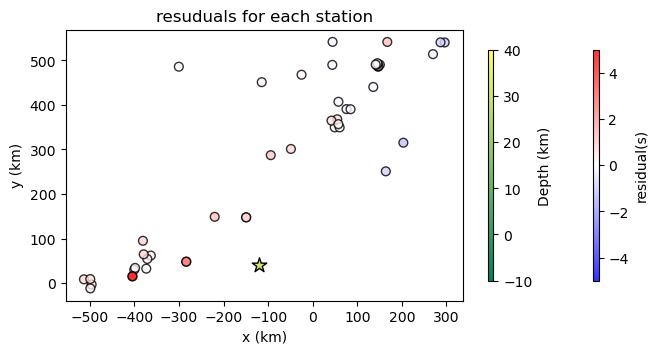

In [79]:
predict_time = calc_time(np.array([[-121.04343593568845, 39.54417880475488, 30.733, -17.9]]), locs, phase_type, config["vel"], config['eikonal'])
plot_residual(data - predict_time, locs, [-121.04343593568845, 39.54417880475488, 30.733])

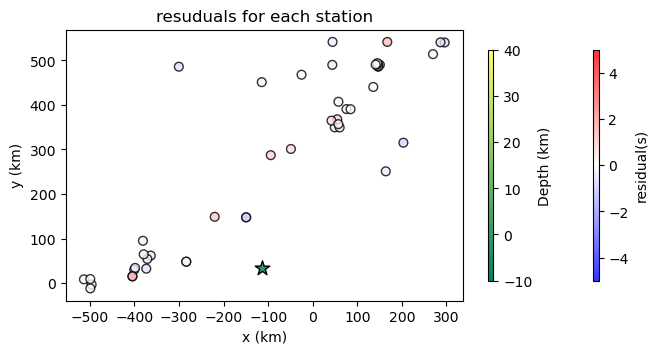

In [59]:
predict_time = calc_time(np.array([[-114.34609896,   34.37192197, 0, -21.13398351]]), locs, phase_type, config["vel"], config['eikonal'])
plot_residual(data - predict_time, locs, [-114.34609896,   34.37192197, 0, -21.13398351])

In [78]:
est_loc

array([[-113.99854925,   33.51819386,    4.20114233,  -20.61900012]])

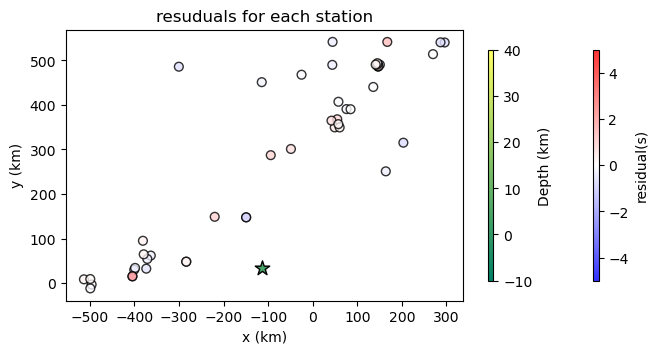

In [77]:
est_loc, mask = ransac(data, phase_type, locs, phase_weight, [-114.34609896,   34.37192197, 0, -21.13398351], config)
predict_time = calc_time(est_loc, locs, phase_type, config["vel"], config['eikonal'])
plot_residual(data - predict_time, locs, np.squeeze(est_loc))

In [ ]:
loss1 = huber_loss_grad(np.squeeze([-121.04343593568845, 39.54417880475488, 30.733, -17.9]), data, phase_type, locs, phase_weight, config["vel"], 0.01, config["eikonal"])
loss2 = huber_loss_grad(np.squeeze([-114.34609896,   34.37192197, 0, -21.13398351]), data, phase_type, locs, phase_weight, config["vel"], 0.01, config["eikonal"])
est_loc, loss = calc_loc(data, phase_type, locs, phase_weight, [-118.33398240307484, 34.433567480553776, 27, -20], config["vel"], config["bfgs_bounds"], eikonal=config["eikonal"])
print("Estimated event location and origin time:", est_loc)
print("Loss:", loss)

In [29]:
from adloc.utils import invert
from adloc.eikonal2d import init_eikonal2d
from adloc.sacloc2d import ADLoc
import pandas as pd
from pyproj import Proj
import numpy as np
from pathlib import Path

mapping_phase_type_int = {"P": 0, "S": 1}

def get_config() -> dict:
    config = {}
    config["minlongitude"] = -164
    config["maxlongitude"] = -148
    config["minlatitude"] = 50
    config["maxlatitude"] = 60
    config["mindepth"] = 0
    config["maxdepth"] = 400
    lon0 = (config["minlongitude"] + config["maxlongitude"]) / 2
    lat0 = (config["minlatitude"] + config["maxlatitude"]) / 2    
    
    config["use_amplitude"] = False

    config["min_picks"] = 6
    config["min_picks_ratio"] = 0.5
    config["max_residual_time"] = 1.0
    config["max_residual_amplitude"] = 1.0
    config["min_picks"] = 6
    config["min_picks_ratio"] = 0.5
    config["max_residual_time"] = 1.0
    config["min_score"] = 0.5
    config["min_s_picks"] = 1.5
    config["min_p_picks"] = 1.5
    config["ncpu"] = 40

    proj = Proj(f"+proj=sterea +lon_0={lon0} +lat_0={lat0} +units=km")
    config["dims"] = ['x(km)', 'y(km)', 'z(km)']
    lt = proj(longitude=config["minlongitude"], latitude=config["minlatitude"])
    lb = proj(longitude=config["minlongitude"], latitude=config["minlatitude"])
    rt = proj(longitude=config["maxlongitude"], latitude=config["maxlatitude"])
    rb = proj(longitude=config["maxlongitude"], latitude=config["maxlatitude"])
    config["xlim_km"] = [min(lt[0], lb[0]), max(rt[0], rb[0])]
    config["ylim_km"] = [min(lb[1], rb[1]), max(lt[1], rt[1])]
    config["zlim_km"] = [config["mindepth"], config["maxdepth"]]

    config["bfgs_bounds"] = (
        (config["xlim_km"][0] - 1, config["xlim_km"][1] + 1),  # x
        (config["ylim_km"][0] - 1, config["ylim_km"][1] + 1),  # y
        (0, config["zlim_km"][1] + 1),  # x
        (None, None),  # t
        )

    # %% Alaska model (averaged from Fan Wang's model)
    config["vel"] = {"P": 6.0, "S": 6.0 / 1.75}
    d, Vp, Vs = np.loadtxt("/mnt/home/jieyaqi/code/AlaskaEQ/data/alaska.csv", usecols=(0, 1, 2), unpack=True, skiprows=1, delimiter=',')
    config["eikonal"] = {"xlim_km": config["xlim_km"], 
                        "ylim_km": config["ylim_km"], 
                        "zlim_km": config["zlim_km"], 
                        "h": 0.5,
                        "vel": {"P": Vp, "S": Vs, "Z": d}}
    config["eikonal"] = init_eikonal2d(config["eikonal"])

    return config, proj

config, proj = get_config()

# %%
workdir = Path('/mnt/scratch/jieyaqi/alaska/final/pntf_alaska_all_iter2')
picks = pd.read_csv('/mnt/scratch/jieyaqi/alaska/final/pntf_alaska_all_iter2/picks_gamma.csv')
picks["phase_time"] = pd.to_datetime(picks["timestamp"])
picks["phase_type"] = picks["type"].map(mapping_phase_type_int)

events = pd.read_csv(workdir / 'catalogs_gamma.csv')
events["time"] = pd.to_datetime(events["time"])
events[["x_km", "y_km"]] = events.apply(
    lambda x: pd.Series(proj(longitude=x.longitude, latitude=x.latitude)), axis=1
)
events["z_km"] = events["depth_km"] if "depth_km" in events.columns else 10.0
events["idx_eve"] = np.arange(len(events))

stations = pd.read_csv('/mnt/home/jieyaqi/code/AlaskaEQ/data/stations.csv')
stations["depth_km"] = -stations["elevation(m)"] / 1000
if "station_term_time_p" not in stations.columns:
    stations["station_term_time_p"] = 0.0
if "station_term_time_s" not in stations.columns:
    stations["station_term_time_s"] = 0.0
if "station_term_amplitude" not in stations.columns:
    stations["station_term_amplitude"] = 0.0
stations[["x_km", "y_km"]] = stations.apply(
    lambda x: pd.Series(proj(longitude=x.longitude, latitude=x.latitude)), axis=1
)
stations["z_km"] = stations["elevation(m)"].apply(lambda x: -x / 1e3)
stations.reset_index(drop=True, inplace=True)
stations["idx_sta"] = np.arange(len(stations))

picks = picks.merge(events[["event_index", "idx_eve"]], on="event_index")
picks = picks.merge(stations[["id", "idx_sta"]], on="id")
picks.drop(["id", "timestamp", "type", "amp", "prob", "event_idx"], axis=1, inplace=True, errors="ignore")

print(f"Number of picks: {len(picks)}")
print(f"Number of events: {len(events)}")

# %%
estimator = ADLoc(config, stations=stations[["x_km", "y_km", "z_km"]].values, eikonal=config["eikonal"])

Eikonal Solver: 
Iter 0, error = 999.903
Iter 1, error = 0.000
Time: 3.151
Eikonal Solver: 
Iter 0, error = 999.831
Iter 1, error = 0.000
Time: 3.117
Number of picks: 5314642
Number of events: 251244


In [28]:
events[events['event_index'] == 131464]

,time,x(km),y(km),z(km),magnitude,sigma_time,sigma_amp,cov_time_amp,event_index,gamma_score,num_picks,num_p_picks,num_s_picks,longitude,latitude,depth(m),x_km,y_km,z_km,idx_eve
131464,2020-09-02 18:36:52.801,-271.048,-22.237,8.793,999,0.578,0,0,131464,10.0,9,6,3,-160.209,54.727,8793.168,-271.055868,-22.24515,10.0,131464


In [ ]:
cat = pd.read_csv()

In [ ]:
def invert(picks, stations, config, estimator, event_index, event_init)``